170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 414s 325ms/step - accuracy: 0.5756 - loss: 1.2072 - val_accuracy: 0.7356 - val_loss: 0.7747
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 452s 333ms/step - accuracy: 0.6403 - loss: 1.0365 - val_accuracy: 0.7388 - val_loss: 0.7705
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 403s 322ms/step - accuracy: 0.6579 - loss: 0.9845 - val_accuracy: 0.7611 - val_loss: 0.7122
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 420s 304ms/step - accuracy: 0.6673 - loss: 0.9565 - val_accuracy: 0.7495 - val_loss: 0.7177
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 404s 322ms/step - accuracy: 0.6720 - loss: 0.9408 - val_accuracy: 0.7638 - val_loss: 0.6931
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.7646 - loss: 0.6837

Test Accuracy: 0.7645999789237976


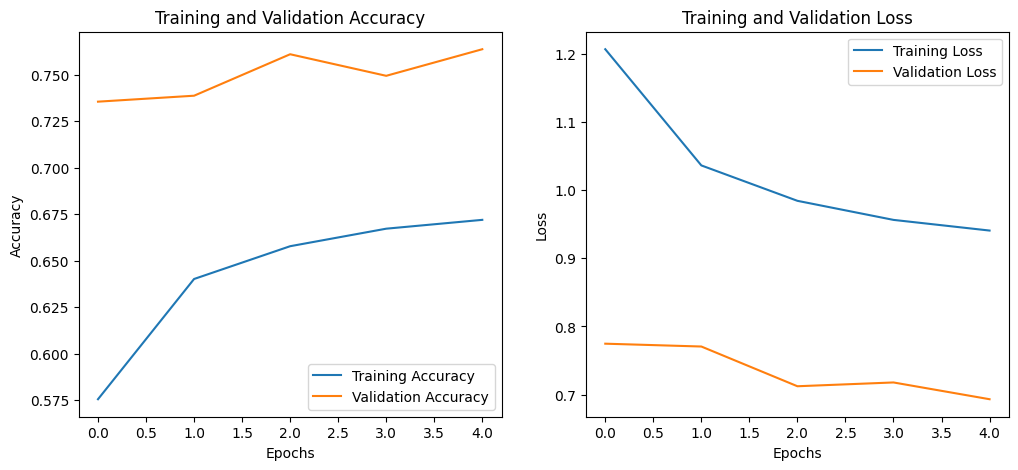


Model saved as cifar10_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predicted Class: cat
Actual Class: cat


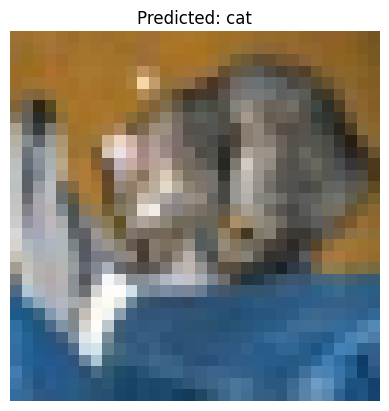

In [1]:


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Load CIFAR-10 Dataset
# ============================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Resize images for MobileNetV2
x_train_resized = tf.image.resize(x_train, (96, 96))
x_test_resized = tf.image.resize(x_test, (96, 96))

# ============================================
# Data Augmentation
# ============================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ============================================
# Load Pretrained Model
# ============================================

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained layers
base_model.trainable = False

# ============================================
# Build Model
# ============================================

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# ============================================
# Compile Model
# ============================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================
# Train Model
# ============================================

history = model.fit(
    x_train_resized,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)



test_loss, test_accuracy = model.evaluate(x_test_resized, y_test)

print("\nTest Accuracy:", test_accuracy)

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


model.save("cifar10_model.h5")

print("\nModel saved as cifar10_model.h5")


sample_image = x_test_resized[0]

prediction = model.predict(
    np.expand_dims(sample_image, axis=0)
)

predicted_class = class_names[np.argmax(prediction)]

print("\nPredicted Class:", predicted_class)
print("Actual Class:", class_names[y_test[0][0]])


plt.imshow(x_test[0])
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()